# Matrix-free CG + stochastic log-det fit (`LLIterative`) vs exact Cholesky

## Context

`LLIterative` is `fit`'s matrix-free alternative to the exact objective
(`objective="LL"`): every term of the concentrated log-likelihood except
$\log|R|$ is computed via conjugate gradient (CG) instead of a dense
$O(n^3)$ Cholesky factorization, and $\log|R|$ itself — the one term CG
cannot produce directly — is replaced by a **Stochastic Lanczos
Quadrature (SLQ)** estimate. This mirrors GPyTorch's BBMM/Lanczos-based
inference strategy (Gardner et al. 2018).

**This notebook is about the numerical methods themselves**: what each
piece computes, why it needs the tricks it needs to actually converge in
practice, and where the resulting log-likelihood agrees with (or drifts
from) the exact one. Everything here is `fit`/log-likelihood; the
matrix-free *predictor* built on the same CG machinery,
`predictIterative`, is deliberately out of scope — see
[predictiterative_vs_cholesky.ipynb](predictiterative_vs_cholesky.ipynb)
for that (§9 below is a one-paragraph pointer, nothing more).

Where `LLIterative` sits relative to the other scaling objectives:

- **`LLVecchia`/`LLNystrom`** trade exactness for a cheaper $R$: each
  evaluation is genuinely $O(n\cdot m^3)$/$O(n\cdot k^2)$ — the objective
  itself approximates a *different, structured* covariance.
- **`LLIterative`** keeps the *true* $R$ throughout: $\hat\beta$/$\hat\sigma^2$/the
  quadratic form are exact up to CG's own tolerance, not a structural
  approximation. Each evaluation is still $O(n^2)$ per CG iteration (or
  one $O(n^2)$ dense build + BLAS-3 matvecs when $R$ fits a memory
  budget) — it doesn't cut the matvec cost the way Vecchia/Nystrom do.
  Its payoff is avoiding the $O(n^3)$ factorization and the $O(n^2)$
  resident factor, same rationale as `predictIterative` but applied to
  *fit*.

See [Iterative.md](Iterative.md) for the full API/parameter reference —
this notebook is its executable, didactic companion, not a replacement.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pylibkriging as lk
import warnings
warnings.filterwarnings('ignore')

lk.set_cuda_iterative_enabled(False)  # CPU/OpenMP path throughout: the numerical
                                      # story here is backend-independent (the
                                      # CUDA-specific optimizations in CHANGELOG.md
                                      # -- device-resident Lanczos, column
                                      # compaction, mixed precision -- change WHERE
                                      # the FLOPs run, not what is being computed)

plt.rcParams['figure.figsize'] = (9, 4.2)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

np.random.seed(42)

## 1. The three approximations, precisely

A Gaussian-process concentrated log-likelihood needs three things from
$R(\theta)$: a linear solve for $\hat\beta$/$\hat\sigma^2$ (the GLS
formulas), the quadratic form inside them, and $\log|R|$ for the
normalizing constant. The exact objective gets all three from one
Cholesky factor $R = LL^\top$. `LLIterative` gets them from three
different, independent numerical devices:

1. **Conjugate gradient for the linear algebra.** One batched CG call
   solves $R^{-1}\cdot[F \mid y]$ (`LinearAlgebra::conjugateGradientBatched`):
   $F$'s few columns and $y$ share the same matvec per iteration, so this
   is $p{+}1$ independent Krylov solves for the cost of one shared
   sweep over $R$ — not block-CG subspace sharing, just amortizing the
   matvec. $\hat\beta$, $\hat\sigma^2$ and the quadratic form then follow
   the *exact same formulas* the Cholesky objective uses; the only
   difference is how $R^{-1}(\cdot)$ was obtained, and CG makes it exact
   up to its own convergence tolerance, not a structural approximation.
2. **Stochastic Lanczos Quadrature (SLQ) for $\log|R|$.** CG solves
   linear systems; it does not produce a determinant. SLQ estimates
   $$
   \log|R| \;\approx\; \frac{n}{n_{\text{probe}}}\sum_{i=1}^{n_{\text{probe}}}
   z_i^\top \log(R)\, z_i
   $$
   by running a *separate*, fully-reorthogonalized Lanczos recurrence on
   each Rademacher probe $z_i\in\{-1,+1\}^n$ (Ubaru, Chen & Saad 2017) —
   $R$ is only ever touched through matvecs, in lockstep across every
   probe, sharing one covariance sweep per Lanczos step.
3. **Hutchinson trace estimate for the gradient.** The envelope-theorem
   gradient needs $\mathrm{tr}(R^{-1}\partial R/\partial\theta_k)$ per
   parameter, estimated as
   $\mathrm{mean}_p\big(w_p\cdot(\partial R/\partial\theta_k\, z_p)\big)$
   where $w_p=R^{-1}z_p$ comes from **one more batched CG call**, reusing
   the *same* probe vectors as SLQ. These are two independent stochastic
   estimators of related but distinct quantities (SLQ is a *truncated
   Lanczos quadrature* of $z^\top\log(R)z$; the gradient's trace term is
   a *plain Hutchinson estimate* using CG-exact $R^{-1}z$) — don't expect
   a tight finite-difference match between the analytic gradient and
   numerical differentiation of the objective.

Item 1 is, in principle, exact. Items 2 and 3 are where `LLIterative`'s
log-likelihood *value* genuinely differs from the Cholesky one — and
that difference, plus everything that makes item 1 actually converge in
finite time on an ill-conditioned $R$, is what the rest of this notebook
measures directly rather than just asserts.

## 2. A running example, and why conditioning is the whole story

One input dimension, points on a **regular grid** (not random — random
placement can cluster two points close together and blow up $\mathrm{cond}(R)$
for reasons that have nothing to do with the method being illustrated,
which would confuse every plot below), a smooth test function with a
little noise.

The central fact that everything below traces back to: for a smooth
covariance kernel like Matérn 5/2, $\mathrm{cond}(R)$ grows **extremely**
fast in $\theta$ (the correlation length) relative to the point
spacing — long before $\theta$ looks "large" in absolute terms. This is
not specific to the iterative objective; it is why the exact objective
needs a numerical nugget on some designs too. It *is* specific to this
notebook's story because CG's convergence rate depends directly on
$\mathrm{cond}(R)$ (and, as §4 shows, on more than just that number).

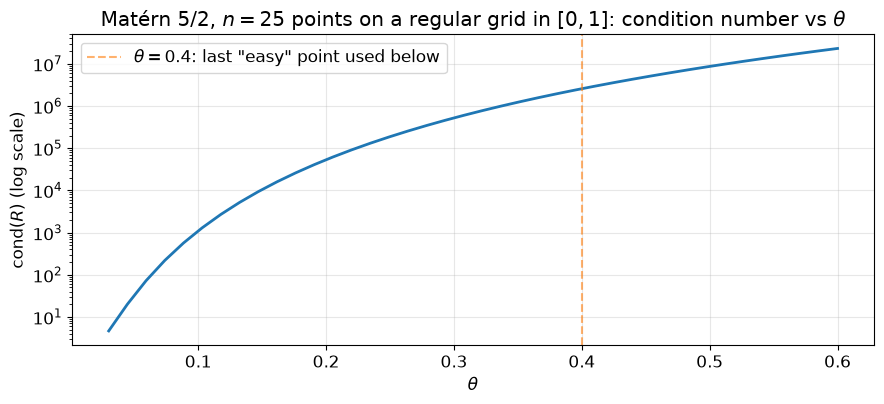

cond(R) at theta=0.05: 2.007e+01
cond(R) at theta=0.20: 6.196e+04
cond(R) at theta=0.40: 2.412e+06
cond(R) at theta=0.60: 2.314e+07

Double precision has ~16 significant decimal digits; once cond(R) approaches
~1e14-1e15, R is numerically singular regardless of the solver -- exact Cholesky
and CG both lose accuracy for the same reason (finite precision), just visibly
differently: Cholesky can still return *a* factor without complaint, CG reports
honestly that it could not reach the requested residual tolerance.


In [2]:
def matern5_2(d, theta):
    r = np.abs(d) / theta
    s5 = np.sqrt(5.0)
    return (1 + s5 * r + 5 * r**2 / 3) * np.exp(-s5 * r)


n = 25
X = np.linspace(0.02, 0.98, n).reshape(-1, 1)


def f(x):
    return np.sin(6 * x) + 0.3 * x


y = f(X[:, 0]) + 0.03 * np.random.randn(n)

D = np.abs(X - X.T)
thetas_cond = np.linspace(0.03, 0.6, 40)
conds = []
for th in thetas_cond:
    w = np.linalg.eigvalsh(matern5_2(D, th))
    conds.append(w[-1] / w[0])

fig, ax = plt.subplots()
ax.semilogy(thetas_cond, conds, lw=2)
ax.axvline(0.4, color='C1', ls='--', alpha=0.6, label=r'$\theta=0.4$: last "easy" point used below')
ax.set_xlabel(r'$\theta$')
ax.set_ylabel(r'$\mathrm{cond}(R)$ (log scale)')
ax.set_title(f'Matérn 5/2, $n={n}$ points on a regular grid in $[0,1]$: condition number vs $\\theta$')
ax.legend()
plt.tight_layout()
plt.show()

print(f'cond(R) at theta=0.05: {conds[np.argmin(np.abs(thetas_cond-0.05))]:.3e}')
print(f'cond(R) at theta=0.20: {conds[np.argmin(np.abs(thetas_cond-0.20))]:.3e}')
print(f'cond(R) at theta=0.40: {conds[np.argmin(np.abs(thetas_cond-0.40))]:.3e}')
print(f'cond(R) at theta=0.60: {conds[np.argmin(np.abs(thetas_cond-0.60))]:.3e}')
print()
print('Double precision has ~16 significant decimal digits; once cond(R) approaches')
print('~1e14-1e15, R is numerically singular regardless of the solver -- exact Cholesky')
print('and CG both lose accuracy for the same reason (finite precision), just visibly')
print('differently: Cholesky can still return *a* factor without complaint, CG reports')
print('honestly that it could not reach the requested residual tolerance.')

## 3. Does the iterative log-likelihood actually track the exact one?

Real `pylibkriging` calls on both sides — `logLikelihoodFun` (exact,
`objective="LL"`) and `logLikelihoodIterativeFun` (`objective="LLIterative(...)"`)
— evaluated at a grid of $\theta$ values on the *same* data, generous CG
settings (`LLIterative(30,0,25,10,1e-6)`: 30 probes, no preconditioner,
25 Lanczos steps — the max useful here since $n=25$ --, a $10n$ iteration
budget, $10^{-6}$ relative-residual tolerance) so that convergence itself
is never in question here (verified below via
`iterative_cg_n_unconverged()`) — every remaining gap between the two
curves is genuinely the SLQ/Hutchinson approximation from §1, not a
linear-solve accuracy artifact. $\theta$ is kept in the range §2 flagged
as numerically comfortable ($\mathrm{cond}(R) \lesssim 10^7$).

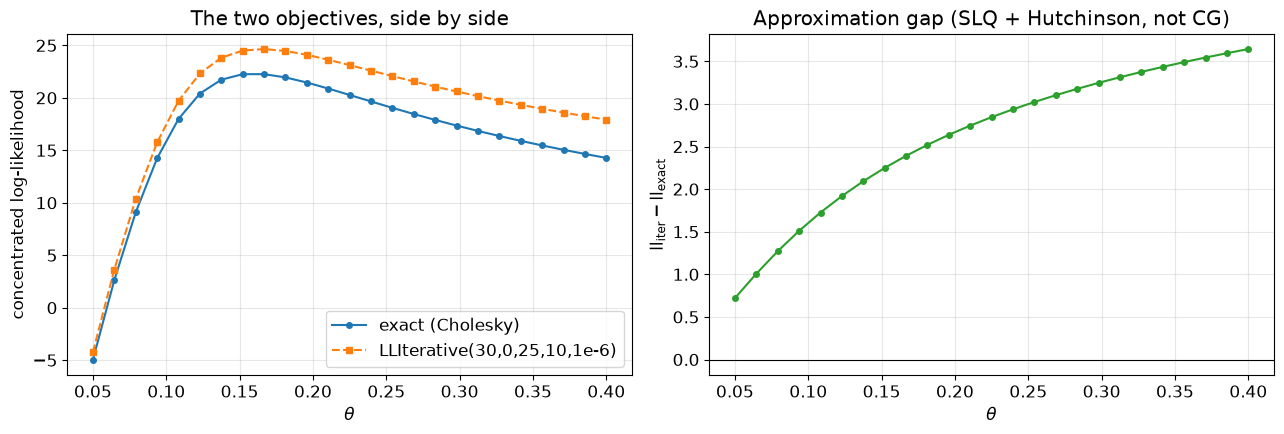

max |n_unconverged| over the scan: 0 (0 = every column, every theta, converged cleanly)
max |ll_iter - ll_exact| over the scan: 3.644
mean |ll_iter - ll_exact| over the scan: 2.621


In [3]:
theta_construct = np.array([[0.2]])
params = {'theta': theta_construct, 'is_theta_estim': False}

k_exact = lk.Kriging(y, X, 'matern5_2', regmodel='constant', objective='LL',
                     optim='none', parameters=params)
k_iter = lk.Kriging(y, X, 'matern5_2', regmodel='constant',
                    objective='LLIterative(30,0,25,10,1e-6)', optim='none', parameters=params)

thetas = np.linspace(0.05, 0.4, 25)
ll_exact = np.array([k_exact.logLikelihoodFun(np.array([th]), False, False)[0] for th in thetas]).ravel()
ll_iter = np.array([k_iter.logLikelihoodIterativeFun(np.array([th]), False)[0] for th in thetas]).ravel()
n_unconv = [k_iter.iterative_cg_n_unconverged() for th in thetas
           for _ in [k_iter.logLikelihoodIterativeFun(np.array([th]), False)]]

fig, (ax, ax_err) = plt.subplots(1, 2, figsize=(13, 4.5))
ax.plot(thetas, ll_exact, 'o-', label='exact (Cholesky)', ms=4)
ax.plot(thetas, ll_iter, 's--', label='LLIterative(30,0,25,10,1e-6)', ms=4)
ax.set_xlabel(r'$\theta$')
ax.set_ylabel('concentrated log-likelihood')
ax.set_title('The two objectives, side by side')
ax.legend()

ax_err.plot(thetas, ll_iter - ll_exact, 'o-', color='C2', ms=4)
ax_err.axhline(0, color='k', lw=0.8)
ax_err.set_xlabel(r'$\theta$')
ax_err.set_ylabel(r'$\mathrm{ll}_{\text{iter}} - \mathrm{ll}_{\text{exact}}$')
ax_err.set_title('Approximation gap (SLQ + Hutchinson, not CG)')
plt.tight_layout()
plt.show()

print(f'max |n_unconverged| over the scan: {max(n_unconv)} (0 = every column, every theta, converged cleanly)')
print(f'max |ll_iter - ll_exact| over the scan: {np.max(np.abs(ll_iter-ll_exact)):.3f}')
print(f'mean |ll_iter - ll_exact| over the scan: {np.mean(np.abs(ll_iter-ll_exact)):.3f}')

## 4. CG convergence: it's not just $\mathrm{cond}(R)$, the right-hand side matters

This is the single most important empirically-found fact behind
`LLIterative`'s tuning knobs (`cg_tol` vs `probes_cg_tol`, below):
**CG's convergence rate depends on how the right-hand side projects onto
$R$'s eigenspectrum, not just $\mathrm{cond}(R)$ alone.** A right-hand side that
is smooth relative to the design (like the regression/response columns
$F$, $y$) concentrates on $R$'s dominant, well-separated eigenmodes and
converges fast. An isotropic Rademacher vector (like SLQ/Hutchinson's
probes) spreads energy across *every* mode, including the tiny
eigenvalues that make $R$ ill-conditioned in the first place, and
converges far slower. This was found the hard way in production — at
$n=8000$ (`bench/gpu`, `matern5_2`, $\theta=0.15$) the probe solve needed
**13470** CG iterations against `[F|y]`'s **1100**, a $12\times$ gap
that only widens with $n$ (see [Iterative.md](Iterative.md)'s table).

The cell below reproduces the *mechanism*, not the production numbers,
with a small, from-scratch, fully-commented reimplementation of the
batched CG algorithm `LinearAlgebra::conjugateGradientBatched` actually
runs (lockstep matvec across every right-hand-side column, per-column
independent stopping, periodic exact-residual restart every 50
iterations) — this is **illustrative code for this notebook**, not the
production C++/CUDA solver, written so the residual history it produces
can be plotted directly (the production solver only reports a final
iteration count, not a per-iteration trace, to Python). It is verified
against a direct dense solve before being trusted for anything below.

cond(R) at n=60, theta=0.25: 3.65e+07
sanity check (separate, tight-tolerance, 3600-iteration run): max|CG - direct solve| = 3.68e-03 (should be small)


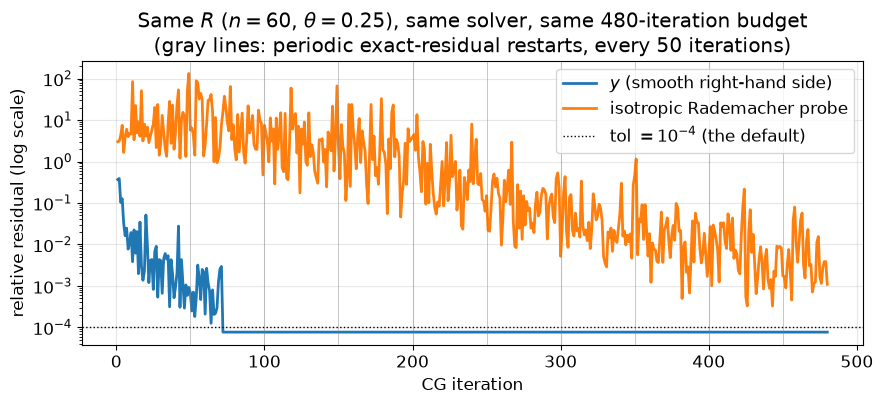

iterations to reach relres < 0.0001 (budget = 480):
  smooth y:          72
  isotropic probe:   did not reach it -- final relres = 1.09e-03


In [4]:
def cg_batched(Rmul, B, max_iter, tol, restart_every=50):
    # Illustrative batched CG with periodic exact-residual restart --
    # same algorithm as LinearAlgebra::conjugateGradientBatched /
    # LinearAlgebraCuda::conjugateGradient, written in numpy purely to
    # expose a per-iteration residual history for plotting.
    n, ncols = B.shape
    Xsol = np.zeros_like(B)
    bnorm = np.linalg.norm(B, axis=0)
    bnorm[bnorm == 0] = 1.0
    R = B.copy()
    P = R.copy()
    rz_old = np.sum(R * R, axis=0)
    active = np.ones(ncols, dtype=bool)
    hist = []
    for it in range(max_iter):
        Ap = Rmul(P)
        pAp = np.sum(P * Ap, axis=0)
        alpha = np.where(active, np.divide(rz_old, pAp, out=np.zeros_like(rz_old), where=pAp != 0), 0.0)
        Xsol += alpha * P
        if (it + 1) % restart_every == 0:
            R_new = B - Rmul(Xsol)  # exact recompute: corrects round-off drift
        else:
            R_new = R - alpha * Ap  # cheap incremental update
        rr_new = np.sum(R_new * R_new, axis=0)
        relres = np.sqrt(rr_new) / bnorm
        active = active & (relres >= tol)
        hist.append(relres.copy())
        if not active.any():
            break
        beta = np.where(active, rr_new / np.where(rz_old == 0, 1.0, rz_old), 0.0)
        P = R_new + beta * P
        R = R_new
        rz_old = rr_new
    return Xsol, np.array(hist)


ncg = 60  # a larger n than the loglik example above: the smooth/isotropic
         # convergence gap needs more spectral room to show up clearly than
         # n=25 gives (this is a SEPARATE, local example -- it does not
         # reuse or overwrite X/y/D/n from the sections above)
Xcg = np.linspace(0.01, 0.99, ncg).reshape(-1, 1)
Dcg = np.abs(Xcg - Xcg.T)
theta_hard = 0.25
Rmat = matern5_2(Dcg, theta_hard)
Rmul = lambda V: Rmat @ V
print(f'cond(R) at n={ncg}, theta={theta_hard}: {np.linalg.cond(Rmat):.2e}')

y_col = (np.sin(6 * Xcg[:, 0]) + 0.3 * Xcg[:, 0]).reshape(-1, 1)
rng = np.random.default_rng(0)
z_col = rng.choice([-1.0, 1.0], size=(ncg, 1))
B = np.hstack([y_col, z_col])

max_iter = 8 * ncg  # a generous 8n budget -- LLIterative's own cg_max_iter_mult knob
Xsol, hist = cg_batched(Rmul, B, max_iter=max_iter, tol=1e-4, restart_every=50)

# Sanity check against a direct dense solve at a much tighter tolerance --
# this illustrative CG must be solving the SAME system as the production
# code, not just "a" system. (cond(R) is large enough here that reaching
# a TIGHT tolerance takes many more iterations than the 8n budget above --
# that is itself an instance of this section's point, not a contradiction.)
Xsol_tight, _ = cg_batched(Rmul, B, max_iter=60 * ncg, tol=1e-8, restart_every=50)
Xtrue = np.linalg.solve(Rmat, B)
max_diff = np.abs(Xsol_tight - Xtrue).max()
print(f'sanity check (separate, tight-tolerance, {60*ncg}-iteration run): '
     f'max|CG - direct solve| = {max_diff:.2e} (should be small)')
assert max_diff < 0.05

fig, ax = plt.subplots()
it_axis = np.arange(1, hist.shape[0] + 1)
ax.semilogy(it_axis, hist[:, 0], label=r'$y$ (smooth right-hand side)', lw=2)
ax.semilogy(it_axis, hist[:, 1], label=r'isotropic Rademacher probe', lw=2)
ax.axhline(1e-4, color='k', ls=':', lw=1, label=r'tol $=10^{-4}$ (the default)')
for r in range(50, hist.shape[0], 50):
    ax.axvline(r, color='gray', lw=0.6, alpha=0.5)
ax.set_xlabel('CG iteration')
ax.set_ylabel('relative residual (log scale)')
ax.set_title(rf'Same $R$ ($n={ncg}$, $\theta={theta_hard}$), same solver, same {max_iter}-iteration budget'
             '\n(gray lines: periodic exact-residual restarts, every 50 iterations)')
ax.legend()
plt.tight_layout()
plt.show()

tol_ref = 1e-4
it_smooth = np.argmax(hist[:, 0] < tol_ref) + 1 if (hist[:, 0] < tol_ref).any() else None
it_iso = np.argmax(hist[:, 1] < tol_ref) + 1 if (hist[:, 1] < tol_ref).any() else None
print(f'iterations to reach relres < {tol_ref} (budget = {max_iter}):')
print(f'  smooth y:          {it_smooth if it_smooth else "did not reach it"}')
print(f'  isotropic probe:   {it_iso if it_iso else f"did not reach it -- final relres = {hist[-1,1]:.2e}"}')

**Why this matters for the tuning knobs.** Because the gradient's
Hutchinson probes are the slow right-hand side and their own estimator
already carries $O(1/\sqrt{n_{\text{probe}}})$ sampling noise (§5), there
is no accuracy reason to solve them to the same tight tolerance as
`[F|y]` — loosening *just* the probe tolerance
(`objective="LLIterative(m,precond_rank,lanczos_steps,cg_max_iter_mult,cg_tol,probes_cg_tol)"`,
6th field) recovers real wall-clock time for free. Measured directly at
$n=8000$: `probes_cg_tol=1e-2` (vs. the shared `1e-4` default) cut the
evaluation from 3.97s to 1.71s with the gradient's accuracy **completely
unaffected**, because the two right-hand-side groups are now fused into
*one* Krylov pass (`LLIterative`'s current mBCG-fusion phase A, §6) that
lets each column carry its own tolerance rather than needing two
separate CG calls at two different tolerances.

**Why the periodic restart matters.** The residual update `R - alpha*Ap`
each iteration is cheap but accumulates floating-point round-off; left
uncorrected over enough iterations it can drift from the *true* residual
`B - Rmul(X)` enough to mislead the stopping test. Every 50 iterations
(gray lines above) the solver instead recomputes the residual exactly
from the current `X` — one extra matvec, paid rarely, that keeps the
whole run numerically honest. This is the *same* restart, incidentally,
that plan item #8 (mixed-precision matvec) piggybacks on: cheap fp32/TF32
matvecs accumulate a *bigger* error between restarts than fp64 round-off
alone, and the periodic exact recompute is what corrects it away — see
`CHANGELOG.md` for where that stops working (very tight tolerances).

## 5. The stochastic log-determinant: two different kinds of error

§3's approximation gap comes from two genuinely different sources, and
telling them apart matters because they respond to *different* knobs:

1. **Lanczos truncation bias** (`lanczos_steps`, default 20): each
   probe's Lanczos quadrature is a *truncated* approximation of
   $z^\top\log(R)z$ that becomes exact as `lanczos_steps` $\to n$. Too few
   steps under-resolve $R$'s spectrum and bias $\log|R|$ — a
   **deterministic** error for a fixed probe set, reducible by raising
   `lanczos_steps` (up to the point of diminishing returns once it's
   resolved enough of the spectrum that matters).
2. **Hutchinson sampling variance** (`nprobe`, the objective's 1st
   field, default 30): even a perfectly-converged Lanczos quadrature per
   probe is still only an $n_{\text{probe}}$-sample Monte Carlo estimate
   of a trace over Rademacher vectors — a **stochastic** error that
   shrinks like $O(1/\sqrt{n_{\text{probe}}})$, not by resolving anything
   more precisely per probe.

Both plots below hold everything else fixed at $\theta=0.35$
($\mathrm{cond}(R)\approx 10^{13}$ per §2 -- deliberately the "hard"
end, where truncation bias is large enough to see clearly) and vary one
knob at a time, comparing against the exact log-likelihood.

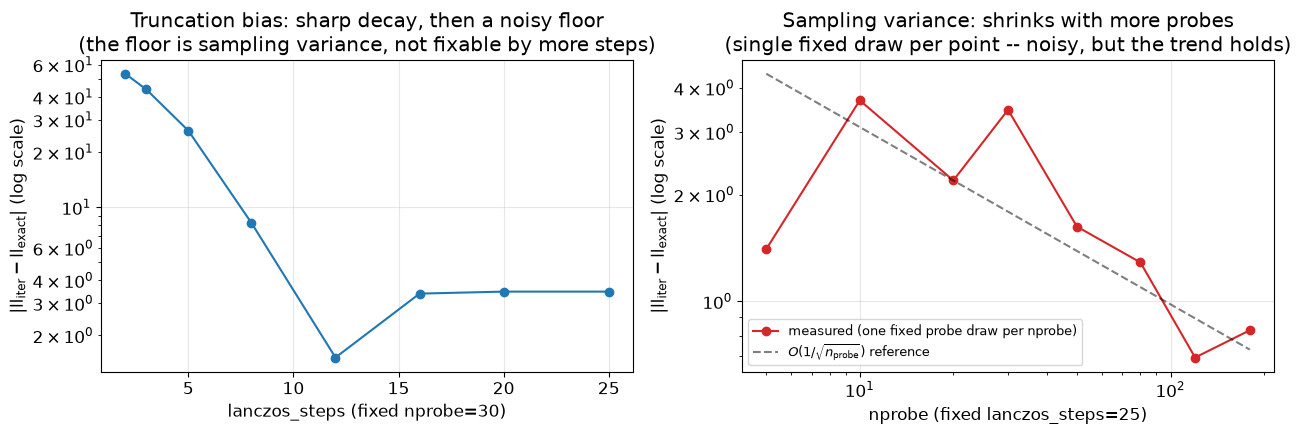

ll_exact at theta=0.35: 15.6468
lanczos_steps sweep: {2: 53.5633, 3: 43.9914, 5: 26.2028, 8: 8.2277, 12: 1.5149, 16: 3.3814, 20: 3.4672, 25: 3.4676}
nprobe sweep:        {5: 1.4024, 10: 3.6868, 20: 2.1915, 30: 3.4676, 50: 1.6233, 80: 1.2871, 120: 0.6937, 180: 0.8281}


In [5]:
theta_slq = 0.35
params_slq = {'theta': np.array([[theta_slq]]), 'is_theta_estim': False}
k_ex_slq = lk.Kriging(y, X, 'matern5_2', regmodel='constant', objective='LL',
                      optim='none', parameters=params_slq)
ll_ex_slq = float(k_ex_slq.logLikelihoodFun(np.array([theta_slq]), False, False)[0])

lanczos_steps_grid = [2, 3, 5, 8, 12, 16, 20, 25]
err_lanczos = []
for ls in lanczos_steps_grid:
    k = lk.Kriging(y, X, 'matern5_2', regmodel='constant',
                  objective=f'LLIterative(30,0,{ls},10,1e-6)', optim='none', parameters=params_slq)
    ll = float(k.logLikelihoodIterativeFun(np.array([theta_slq]), False)[0])
    err_lanczos.append(abs(ll - ll_ex_slq))

nprobe_grid = [5, 10, 20, 30, 50, 80, 120, 180]
err_nprobe = []
for npb in nprobe_grid:
    k = lk.Kriging(y, X, 'matern5_2', regmodel='constant',
                  objective=f'LLIterative({npb},0,25,10,1e-6)', optim='none', parameters=params_slq)
    ll = float(k.logLikelihoodIterativeFun(np.array([theta_slq]), False)[0])
    err_nprobe.append(abs(ll - ll_ex_slq))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
ax1.semilogy(lanczos_steps_grid, err_lanczos, 'o-', color='C0')
ax1.set_xlabel('lanczos_steps (fixed nprobe=30)')
ax1.set_ylabel(r'$|\mathrm{ll}_{\text{iter}} - \mathrm{ll}_{\text{exact}}|$ (log scale)')
ax1.set_title('Truncation bias: sharp decay, then a noisy floor\n(the floor is sampling variance, not fixable by more steps)')

ax2.loglog(nprobe_grid, err_nprobe, 'o-', color='C3', label='measured (one fixed probe draw per nprobe)')
ref = err_nprobe[2] * np.sqrt(nprobe_grid[2] / np.array(nprobe_grid, dtype=float))
ax2.loglog(nprobe_grid, ref, 'k--', alpha=0.5, label=r'$O(1/\sqrt{n_{\mathrm{probe}}})$ reference')
ax2.set_xlabel('nprobe (fixed lanczos_steps=25)')
ax2.set_ylabel(r'$|\mathrm{ll}_{\text{iter}} - \mathrm{ll}_{\text{exact}}|$ (log scale)')
ax2.set_title('Sampling variance: shrinks with more probes\n(single fixed draw per point -- noisy, but the trend holds)')
ax2.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'll_exact at theta={theta_slq}: {ll_ex_slq:.4f}')
print('lanczos_steps sweep:', dict(zip(lanczos_steps_grid, [round(e,4) for e in err_lanczos])))
print('nprobe sweep:       ', dict(zip(nprobe_grid, [round(e,4) for e in err_nprobe])))

**Reading the two plots together**: the left plot's error drops
sharply from `lanczos_steps=2` to about `12` (each extra step resolves
more of $R$'s spectrum) and then levels off into a noisy band that more
steps do not shrink — because what's left there is sampling noise from a
*finite* `nprobe` (right plot), not truncation. Raising `lanczos_steps`
past the point where the bias has plateaued does nothing for the
remaining error; only more probes do. This is exactly the production
finding at $n=8000$ (`Iterative.md`'s `cg_tol` table): eight orders of
magnitude of *extra linear-solve accuracy* bought **zero** improvement in
the returned log-likelihood, because the SLQ/Hutchinson noise floor
already dominated. Tightening the wrong knob is a common, easy-to-make
mistake with this objective — check which error source actually
dominates (a quick `LLIterative(m)` vs `LLIterative(m,0,more_steps)`
comparison, same as this section) before spending iteration budget on
`cg_tol`.

## 6. Reusing the same Krylov pass: mBCG fusion, and where it stops

Production `LLIterative` does not actually run `[F|y]`'s CG solve and
the Hutchinson probes' CG solve as two separate calls when a gradient is
requested — it fuses them into **one** batched Krylov pass over
`[F|y|probes]`, since a batched matvec already shares one covariance
sweep across however many right-hand-side columns are in the block (§1
already amortizes this within `[F|y]`; the fusion just widens the block
to include the probes too, letting each column stop at its *own*
tolerance thanks to the per-column tolerance vector §4 already needed
for `cg_tol` vs `probes_cg_tol`). Real, safe, shipped.

The tempting next step — reading the SLQ log-determinant directly off
that *same* fused CG call's own $\alpha$/$\beta$ coefficients (the
CG-Lanczos duality underlying true "matrix-free BBMM": no dedicated
Lanczos recurrence at all, zero extra matvecs) — was tried and
deliberately **not** kept. A from-scratch check of the duality itself
was fine (0.5% error at $n=2000$, actually *better* than the fixed-step
dedicated Lanczos it would have replaced), but production's periodic
CG restart (§4) fragments the implicit Lanczos recurrence into
independent segments, and reconstructing the quadrature from only the
most recent segment turned out to depend on pure luck — whether the
number of iterations needed happens to land near a restart boundary
(50→237% error, wrong-signed; 1000→0.1% by a lucky near-alignment).
Neither obvious fix is a quick patch (combining segments risks a
systematic bias; loosening the restart cadence reopens the round-off
risk it exists to correct, worst exactly where it's already documented
as marginal). See [MBCGLogDet.md](MBCGLogDet.md) for the full
investigation, tables included, if you're tempted to revisit this.

## 7. The Nystrom-Woodbury CG preconditioner: real, but not a free lunch

`objective="LLIterative(m,precond_rank)"` opts every CG solve (and the
SLQ quadrature itself, run on the whitened $\tilde R = L^{-1}RL^{-\top}$
instead of $R$) into a rank-`precond_rank` Nystrom-Woodbury
preconditioner built from a fixed landmark set — the same idea as
`LLNystrom`'s landmarks and `predictIterative`'s own preconditioner
option. A better-conditioned $\tilde R$ needs fewer Krylov iterations
for the same tolerance, **and** tightens the SLQ bias (§5's left plot)
for the same `lanczos_steps`, since the quadrature is now resolving the
whitened operator's milder spectrum.

**It is not automatically a win**, which is why it defaults to off
(`precond_rank` omitted or 0). Unlike `predictIterative` (preconditioned
once, at an already-fitted $\theta$), `LLIterative`'s preconditioner is
rebuilt from the fixed landmarks **at the current $\theta$, on every
single objective/gradient evaluation** — real $O(n\cdot
\text{precond\_rank}^2)$ setup cost paid every time BFGS asks for a new
$\theta$. Measured directly at $n=8000$: raising `precond_rank` to 256
cut the probe solve's iteration count (13470 → 7200) but the rebuild
cost more than ate the saving — net wall time got *worse* (3.97s →
7.16s). Whether it helps depends on how large $n$ is relative to how
expensive the *un*-preconditioned solve already is; it is worth trying,
not worth assuming.

## 8. GPU-specific optimizations (brief pointer)

Everything above is about the *numerical method*; several optimizations
this project has since added change *where the FLOPs run*, not what is
computed, and are consequently outside this notebook's scope (they're
exhaustively measured, with honest positive-and-negative findings, in
`CHANGELOG.md` and `docs/math/Iterative.md`):

- A **device-resident dense $R$/SLQ path** on CUDA (materialize $R$ once
  per evaluation, then BLAS-3 matvecs) — ~25-114x at moderate $n$.
- **mBCG fusion phase A** (§6) — the safe half of the CG-Lanczos duality
  story, ~17-24% faster on top of the above.
- **Column compaction** in the batched CG — drop an already-converged
  column out of the working set instead of carrying it through every
  remaining matvec — ~7.4x on the matrix-free path specifically (large
  $n$, many right-hand-side columns converging at very different rates,
  exactly §4's phenomenon at scale); no effect on the dense path (its
  matvec is memory-bandwidth-bound on $R$ itself, not on the column
  count).
- An **opt-in mixed-precision matvec** (TF32/fp32 + periodic fp64
  restart correction, §4) — ~5x on an fp64-throttled GPU (L40S), ~1.1x
  on one that isn't (H100), with a real accuracy floor at tight
  tolerances (documented, not hidden).

None of these change the log-likelihood *value* (bit-identical to the
SLQ/Hutchinson noise floor) — they only change how fast it's obtained on
a given backend.

## 9. `predictIterative` (one paragraph, not a section)

Once a model is fitted (however it got there), `predictIterative` is a
*separate*, non-stochastic matrix-free predictor built on the same CG
machinery: one CG solve per test point (two with `return_stdev`), no
SLQ, no Hutchinson estimator. It is thoroughly benchmarked on its own —
worked correctness example, memory/speed scaling — in
[predictiterative_vs_cholesky.ipynb](predictiterative_vs_cholesky.ipynb),
which this notebook deliberately does not duplicate.

## 10. Exact Cholesky vs `LLIterative`, side by side

| | exact (`objective="LL"`) | `LLIterative` |
|---|---|---|
| $\hat\beta$/$\hat\sigma^2$/quadratic form | exact (one Cholesky factor) | exact up to CG's `cg_tol` (not a structural approximation) |
| $\log\lvert R\rvert$ | exact | **stochastic** (SLQ): truncation bias (`lanczos_steps`) + sampling variance (`nprobe`) |
| gradient | exact analytic | Hutchinson estimate, independent of the SLQ estimator |
| determinism | fully deterministic | deterministic **given fixed probes** (drawn once, reused across every $\theta$ in one fit) |
| memory | resident $O(n^2)$ factor | $R$ never needs to be resident (matrix-free), or built once and reused (dense fast path) if it fits a budget |
| compute per evaluation | $O(n^3)$ | $O(n^2)$ per CG/Lanczos matvec $\times$ (iterations to `cg_tol` + `lanczos_steps`) |
| failure mode at extreme $\mathrm{cond}(R)$ | silently returns *a* factor (may need a numerical nugget) | CG honestly reports non-convergence (`iterative_cg_n_unconverged()`, a `[WARNING]`) |
| use it when | $n$ small enough that $O(n^3)$/$O(n^2)$ is affordable, and you want the reference-quality answer | $n$ large enough that a resident factor is the actual blocker, and a percent-level stochastic log-determinant is acceptable |

The failure-mode row is worth dwelling on: an ill-conditioned $R$ is hard
for *both* methods (§2), but `LLIterative` is the one that tells you
about it explicitly rather than quietly returning a less-trustworthy
answer.

## Practical guidance

- Start with the defaults (`objective="LLIterative(m)"`, $m\approx 30$
  probes). Reach for `lanczos_steps` (§5) if the log-likelihood *value*
  looks biased against a spot-check with the exact objective at a
  trusted $\theta$; reach for `probes_cg_tol` (§4) if evaluations are
  slow and the gradient is what you actually need accurately; reach for
  `precond_rank` (§7) if $n$ is large enough that CG's own iteration
  count is the dominant cost — but measure, don't assume, since it has a
  real, non-trivial setup cost of its own.
- `NoiseModel::None` only in the current version; `simulate`/
  `update_simulate`/`save` are blocked on `LLIterative`-fitted models (no
  matrix-free sampling technique implemented yet).
- `optim="none"` at a fixed $\theta$ commits a light `LLIterative` fit
  too (like `LLNystrom` always did) — the fast, deterministic way to get
  an `LLIterative`-flavored model without paying for a BFGS search, used
  throughout this notebook.
- For the performance side of this story (GPU backends, memory/time
  scaling with $n$, the full history of what was tried and rejected) see
  `CHANGELOG.md` and [Iterative.md](Iterative.md) — this notebook is
  deliberately just the numerical-methods story.

## References

- Ubaru, S., Chen, J., & Saad, Y. (2017). *Fast estimation of tr(f(A)) via
  stochastic Lanczos quadrature*. SIAM Journal on Matrix Analysis and
  Applications, 38(4), 1075-1099.
- Hutchinson, M. F. (1990). *A stochastic estimator of the trace of the
  influence matrix for Laplacian smoothing splines*. Communications in
  Statistics - Simulation and Computation, 19(2), 433-450.
- Gardner, J., Pleiss, G., Weinberger, K. Q., Bindel, D., & Wilson, A. G.
  (2018). *GPyTorch: Blackbox matrix-matrix Gaussian process inference
  with GPU acceleration*. Advances in Neural Information Processing
  Systems, 31 — the BBMM strategy this objective mirrors.
- Hestenes, M. R., & Stiefel, E. (1952). *Methods of conjugate gradients
  for solving linear systems*. Journal of Research of the National Bureau
  of Standards, 49(6), 409-436 — the original CG method underlying every
  matrix-free solve used here.

See also [Iterative.md](Iterative.md) for the full API reference,
[MBCGLogDet.md](MBCGLogDet.md) for the mBCG phase B investigation (§6),
[PredictIterative.md](PredictIterative.md) for the matrix-free predictor
this reuses, and [Scalability.md](Scalability.md) for how `LLIterative`
compares to `LLVecchia`, `LLNystrom`, `NestedKriging` and `subsetOfData`.